In [10]:
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"       # HRM-Text
MUTED = "#7f8c8d"        # generic baseline
TRM_COLOR = "#2c6fbb"    # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


# Readable model labels keyed by the run's config_name.
MODEL_LABELS = {
    "hrm_text": "HRM-Text-1B",
    "baseline_1b": "Qwen2.5-1.5B",
    "meta-icl-1b": "Qwen2.5-1.5B (Meta-ICL)",
    "baseline": "GPT-2",
    "meta-icl": "GPT-2 (Meta-ICL)",
}

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]


In [11]:
performance_data = pd.read_csv("data/results/performance_data.csv")
ablation_data = pd.read_csv("data/results/ablation_data.csv")

In [8]:
performance_data.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,config_name,dataset,...,curriculum/count_CycleCheck,curriculum/count_DisconnectedNodes,curriculum/count_EdgeCount,curriculum/count_EdgeExistence,curriculum/count_MaximumFlow,curriculum/count_NodeCount,curriculum/count_NodeDegree,curriculum/count_Reachability,curriculum/count_ShortestPath,curriculum/count_TriangleCounting
0,baseline-1b-ood-MaximumFlow,finished,-,NaN,NaN,2026-07-29T07:28:12.000Z,73,NaN,baseline_1b,"{'name': 'graphqa', 'test_type': 'ood', 'datas...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hrm-text-id,finished,-,NaN,NaN,2026-07-29T07:27:57.000Z,15,NaN,hrm_text,"{'name': 'graphqa', 'test_type': 'standard', '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
ablation_data.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,H_cycles,L_cycles,ckpt_path,data,max_generation,ratio_L_over_H,use_ema,eval/accuracy,eval/correct,eval/n
0,graphqa_H1_L12,finished,-,NaN,"H1, L12, ablation",2026-08-01T16:40:44.000Z,8,NaN,1,12,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,12.0,True,0.516883,199.0,385.0
1,graphqa_H2_L6,finished,-,NaN,"H2, L6, ablation",2026-08-01T16:41:00.000Z,7,NaN,2,6,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,3.0,True,0.441558,170.0,385.0


# RQ1 — Performance: HRM-Text vs. baselines

In-distribution (`standard`) exact-match accuracy on GraphQA. HRM-Text-1B is compared
against Qwen2.5-1.5B and GPT-2 backbones, each in a direct fine-tuning setting and a
Meta-ICL variant. Duplicate runs are de-duplicated by keeping the most recent one.


In [12]:
# Parse the dict-string `dataset` column to recover the evaluation test_type.
perf = performance_data.copy()
perf["test_type"] = perf["dataset"].map(lambda s: eval(s)["test_type"])

# Keep in-distribution runs only, then keep the most recent run per model.
perf_id = (
    perf[perf["test_type"] == "standard"]
    .sort_values("Created")
    .drop_duplicates(subset="config_name", keep="last")
    .copy()
)
perf_id["model"] = perf_id["config_name"].map(MODEL_LABELS)
perf_id = perf_id.dropna(subset=["model"])

overall = (
    perf_id[["model", "val/exact_match"]]
    .rename(columns={"val/exact_match": "exact_match"})
    .sort_values("exact_match", ascending=False)
    .reset_index(drop=True)
)
overall


,model,exact_match
0,HRM-Text-1B,0.833766
1,Qwen2.5-1.5B,0.719481
2,Qwen2.5-1.5B (Meta-ICL),0.714286
3,GPT-2 (Meta-ICL),0.605195
4,GPT-2,0.600000


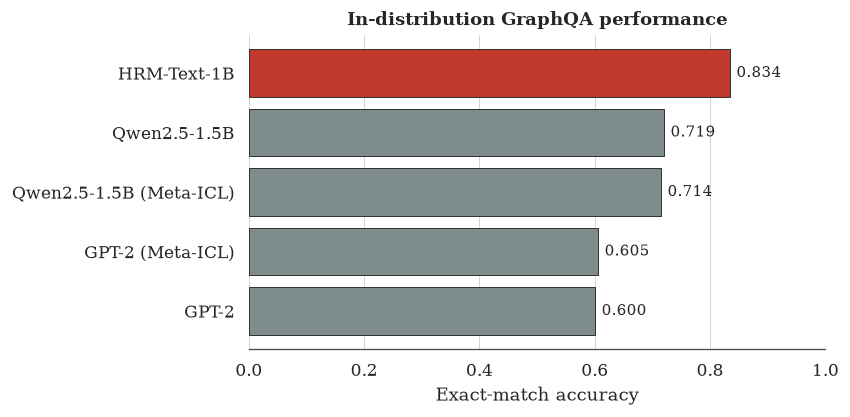

In [13]:
# Overall exact-match: HRM-Text highlighted, baselines muted.
fig, ax = plt.subplots(figsize=(6.2, 3.4))
colors = [ACCENT if m == "HRM-Text-1B" else MUTED for m in overall["model"]]
bars = ax.barh(overall["model"], overall["exact_match"], color=colors, edgecolor="0.2", linewidth=0.6)
ax.invert_yaxis()  # best model on top
ax.set_xlabel("Exact-match accuracy")
ax.set_xlim(0, 1.0)
ax.set_title("In-distribution GraphQA performance")

for bar, v in zip(bars, overall["exact_match"]):
    ax.text(v + 0.012, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
            va="center", ha="left", fontsize=9)

sns.despine(ax=ax, left=True)
ax.grid(axis="y", visible=False)
save_fig(fig, "perf_overall")
plt.show()


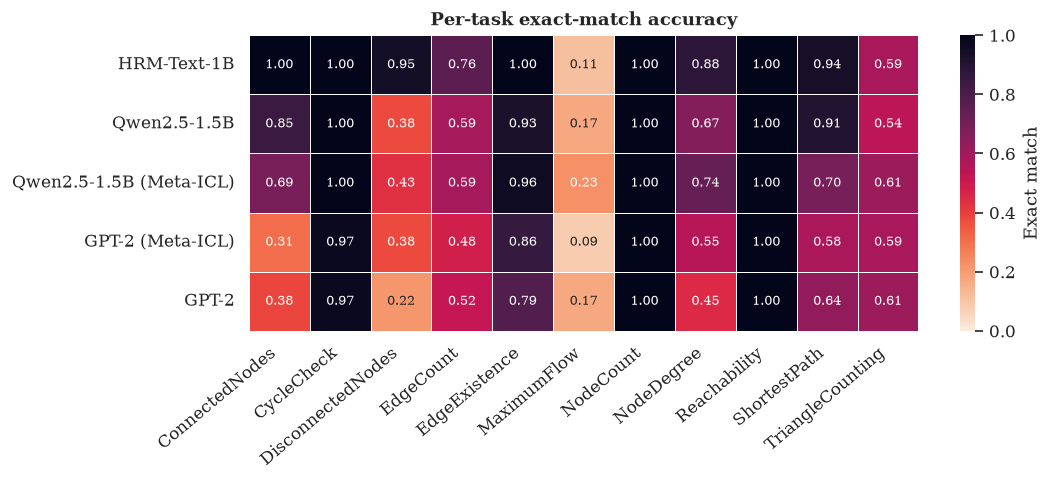

In [14]:
# Per-task exact-match: models x 11 GraphQA tasks.
task_cols = [f"val/exact_match_{t}" for t in GRAPH_TASKS]
bytask = perf_id.set_index("model")[task_cols]
bytask.columns = GRAPH_TASKS
bytask = bytask.reindex(overall["model"])  # order by overall accuracy

fig, ax = plt.subplots(figsize=(9.0, 3.2))
sns.heatmap(
    bytask, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Exact match"},
    annot_kws={"fontsize": 8}, ax=ax,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("Per-task exact-match accuracy")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
save_fig(fig, "perf_by_task")
plt.show()


# RQ2 — Ablation: the L/H ratio drives performance

Two effects on GraphQA test accuracy:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio, whereas ratios below
   1 collapse performance.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H$ fixed and simply scaling up
   the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [15]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs.
abl = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
abl


,family,H,L,ratio,accuracy
4,HRM,4,3,0.750000,0.062338
3,HRM,3,4,1.333333,0.397403
1,HRM,2,3,1.500000,0.444156
5,HRM,6,9,1.500000,0.000000
6,HRM,8,12,1.500000,0.000000
2,HRM,2,6,3.000000,0.441558
0,HRM,1,12,12.000000,0.515584
7,TRM,2,3,1.500000,0.477922
8,TRM,4,6,1.500000,0.407792
9,TRM,8,12,1.500000,0.000000


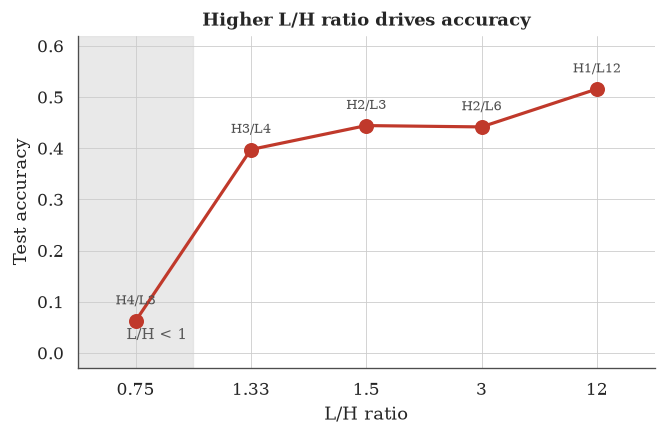

In [19]:
# Axis 2 — ratio effect. Use the smallest-scale HRM run per ratio to isolate ratio
# from total recurrence depth. Evenly-spaced categorical x-axis keeps close ratios legible.
hrm = abl[abl["family"] == "HRM"]
ratio_curve = (
    hrm.sort_values("H")
    .drop_duplicates(subset="ratio", keep="first")
    .sort_values("ratio")
    .reset_index(drop=True)
)
x = np.arange(len(ratio_curve))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
sub_one = ratio_curve["ratio"] < 1
ax.axvspan(-0.5, sub_one.sum() - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(sub_one.sum() - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

ax.plot(x, ratio_curve["accuracy"], marker="o", color=ACCENT, markersize=8,
        linewidth=1.9, zorder=3)
for xi, r in zip(x, ratio_curve.itertuples()):
    ax.annotate(f"H{r.H}/L{r.L}", (xi, r.accuracy), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="0.3")

ax.set_xticks(x)
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratio_curve["ratio"]])
ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xlabel("L/H ratio")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


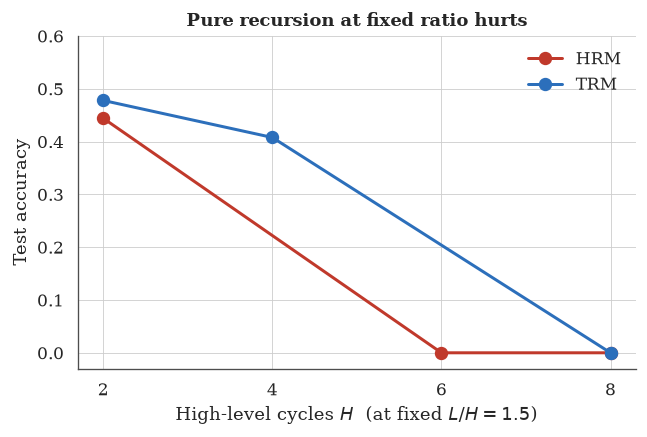

In [17]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()
